In [1]:
import pandas as pd
import numpy as np
root="/home/jacoponudo/Documents/Virality-on-Shorts/" # TO CHANGE according to your local path

# Data loading
instagram = pd.read_csv(root + "data/clean/instagram.csv")
tiktok = pd.read_csv(root + "data/clean/tiktok.csv")
youtube = pd.read_csv(root + "data/clean/youtube.csv")


## Filter on just active channels for each year

In [16]:
# Filtering active publishers
from tools import filter_active_publisher_years

youtube_active, yt_publishers, yt_counts = filter_active_publisher_years(
    df=youtube,
    platform_name="YouTube",
    publisher_col="publisher",
    date_col="published_at",
    min_videos_per_year=1
)

instagram_active, ig_publishers, ig_counts = filter_active_publisher_years(
    df=instagram,
    platform_name="Instagram",
    publisher_col="publisher",
    date_col="published_at",
    min_videos_per_year=1
)

tiktok_active, tt_publishers, tt_counts = filter_active_publisher_years(
    df=tiktok,
    platform_name="TikTok",
    publisher_col="publisher",
    date_col="published_at",
    min_videos_per_year=1
)


YouTube
-------
Original videos:              51,863
Original publishers:          130
Videos after filtering:       51,863
Unique publishers retained:   130

Publisher-years retained by year:
year
2022     62
2023     83
2024     96
2025    103
2026     98
Name: count, dtype: int64

Instagram
---------
Original videos:              235,743
Original publishers:          161
Videos after filtering:       235,743
Unique publishers retained:   161

Publisher-years retained by year:
year
2022    131
2023    154
2024    156
2025    159
2026    150
Name: count, dtype: int64

TikTok
------
Original videos:              195,672
Original publishers:          160
Videos after filtering:       195,672
Unique publishers retained:   160

Publisher-years retained by year:
year
2022     68
2023     99
2024    118
2025    137
2026    138
Name: count, dtype: int64


# Virality

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
all_vc = pd.concat([instagram_active, tiktok_active, youtube_active], ignore_index=True)


/tmp/ipykernel_2360825/1540055654.py:83: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['year_month'] = df['published_at'].dt.to_period('M')


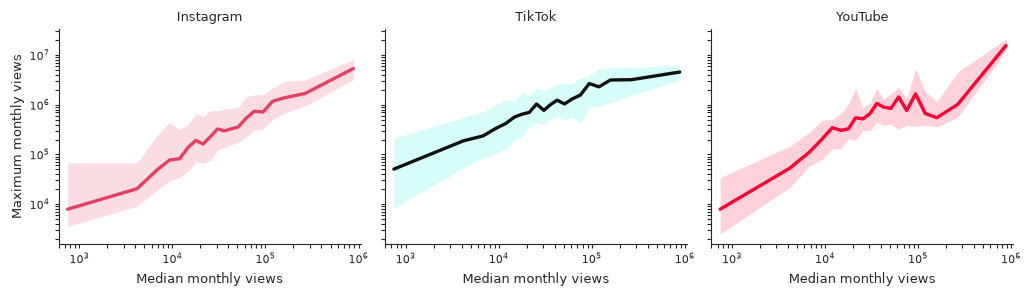

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =============================================================================
# PARAMETERS
# =============================================================================

# Minimum number of videos required for a publisher in a month.
# Publisher-month combinations with fewer videos are discarded.
MIN_VIDEOS_PER_MONTH = 5

# Number of quantile bins used to divide the Instagram median monthly views.
# Example:
#   10 = deciles
#   20 = ventiles (5% bins)
N_QUANTILES = 20

# Statistic used to summarize monthly views for each publisher.
# Options include "median" or "mean".
MONTHLY_VIEW_STAT = "median"

# Figure layout
N_COLUMNS = 3          # Number of columns in the facet grid
PANEL_HEIGHT = 3.0     # Height of each subplot (inches)
PANEL_ASPECT = 1.15    # Width / height ratio

# Transparency of the interquartile range (IQR) ribbon
IQR_ALPHA = 0.18

# Thickness of the median line
LINE_WIDTH = 2.4

# Axis scale ("linear" or "log")
X_SCALE = "log"
Y_SCALE = "log"

# Plot colors for each platform
LINE_COLORS = {
    "Instagram": "#E4405F",
    "TikTok": "#111111",
    "YouTube": "#FF0033",
}

FILL_COLORS = {
    "Instagram": "#E4405F",
    "TikTok": "#25F4EE",
    "YouTube": "#FF0033",
}

# =============================================================================
# STYLE
# =============================================================================

sns.set_theme(
    style="ticks",
    context="paper",
    font_scale=1.1,
)

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 8,
    "axes.labelsize": 9,
    "axes.titlesize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# =============================================================================
# DATA PREPARATION
# =============================================================================

df = all_vc[['publisher', 'platform', 'published_at', 'views']].copy()
df['published_at'] = pd.to_datetime(df['published_at'])
df['year_month'] = df['published_at'].dt.to_period('M')

agg = (
    df.groupby(['publisher', 'platform', 'year_month'])['views']
    .agg(
        views_mean=MONTHLY_VIEW_STAT,
        views_max='max',
        n_videos='count'
    )
    .reset_index()
)

agg = agg[agg['n_videos'] >= MIN_VIDEOS_PER_MONTH]
agg = agg[(agg['views_mean'] > 0) & (agg['views_max'] > 0)]

# =============================================================================
# QUANTILE BINS (computed only on Instagram)
# =============================================================================

instagram_mean = agg.loc[
    agg['platform'] == 'Instagram',
    'views_mean'
]

_, bin_edges = pd.qcut(
    instagram_mean,
    q=N_QUANTILES,
    labels=False,
    duplicates='drop',
    retbins=True
)

bin_edges_ext = bin_edges.copy()
bin_edges_ext[0] = -np.inf
bin_edges_ext[-1] = np.inf

agg['decile'] = pd.cut(
    agg['views_mean'],
    bins=bin_edges_ext,
    labels=False,
    include_lowest=True
)

bin_centers = [
    np.sqrt(bin_edges[i] * bin_edges[i + 1])
    for i in range(len(bin_edges) - 1)
]

# =============================================================================
# SUMMARY STATISTICS
# =============================================================================

summary = (
    agg.groupby(["platform", "decile"])
       .agg(
           median=("views_max", "median"),
           q25=("views_max", lambda x: x.quantile(0.25)),
           q75=("views_max", lambda x: x.quantile(0.75)),
       )
       .reset_index()
)

summary["x"] = summary["decile"].map(
    dict(enumerate(bin_centers))
)

# =============================================================================
# PLOT
# =============================================================================

g = sns.FacetGrid(
    summary,
    col="platform",
    col_wrap=N_COLUMNS,
    height=PANEL_HEIGHT,
    aspect=PANEL_ASPECT,
    sharex=True,
    sharey=True,
    despine=True,
)

def plot_platform(data, **kwargs):

    ax = plt.gca()
    platform = data["platform"].iloc[0]

    ax.fill_between(
        data["x"],
        data["q25"],
        data["q75"],
        color=FILL_COLORS[platform],
        alpha=IQR_ALPHA,
        linewidth=0,
    )

    ax.plot(
        data["x"],
        data["median"],
        color=LINE_COLORS[platform],
        lw=LINE_WIDTH,
        solid_capstyle="round",
    )

    ax.set_xscale(X_SCALE)
    ax.set_yscale(Y_SCALE)

    sns.despine(ax=ax)

g.map_dataframe(plot_platform)

g.set_axis_labels(
    "Median monthly views",
    "Maximum monthly views",
)

g.set_titles("{col_name}")

for ax in g.axes.flat:
    ax.tick_params(length=3, width=0.8)
    ax.set_xlim(
        min(bin_centers) * 0.8,
        max(bin_centers) * 1.2
    )

plt.tight_layout()

# plt.savefig("figure.pdf", dpi=600, bbox_inches="tight")
plt.show()

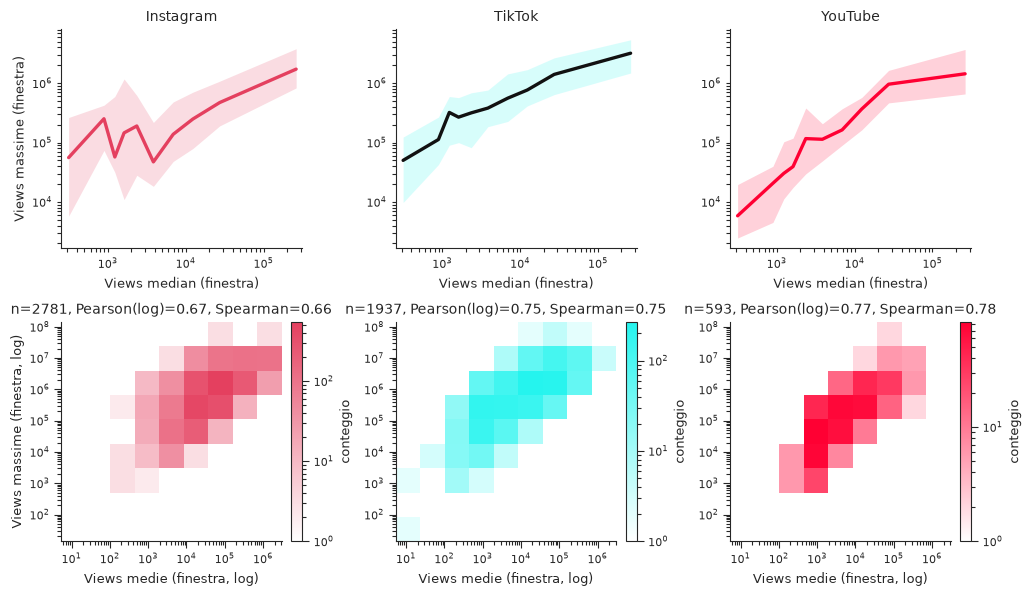

    platform time_window  n_points  pearson_r_log  pearson_p_log  spearman_r  \
0  Instagram           M      2781       0.670124   0.000000e+00    0.656433   
1     TikTok           M      1937       0.745607   0.000000e+00    0.752436   
2    YouTube           M       593       0.772974  6.904128e-119    0.784004   

      spearman_p  
0   0.000000e+00  
1   0.000000e+00  
2  1.727161e-124  


<Figure size 640x480 with 0 Axes>

    platform time_window  n_points  pearson_r_log  pearson_p_log  spearman_r  \
0  Instagram           M      2781       0.670124   0.000000e+00    0.656433   
1     TikTok           M      1937       0.745607   0.000000e+00    0.752436   
2    YouTube           M       593       0.772974  6.904128e-119    0.784004   
3  Instagram           M      2781       0.670039            NaN    0.656903   
4     TikTok           M      1937       0.745813            NaN    0.752413   
5    YouTube           M       593       0.773324            NaN    0.783451   

      spearman_p  
0   0.000000e+00  
1   0.000000e+00  
2  1.727161e-124  
3            NaN  
4            NaN  
5            NaN  


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

# =============================================================================
# PARAMETERS
# =============================================================================

TIME_WINDOW = "M"
_WINDOW_MONTHS = {"M": 1, "Q": 3, "6M": 6, "A": 12}

MIN_VIDEOS_PER_WINDOW = 30
MIN_VIDEOS_PER_WINDOW_SCATTER = 30

N_BOOTSTRAP = 100

N_QUANTILES = 10
WINDOW_VIEW_STAT = "median"

PANEL_HEIGHT = 3.0
PANEL_WIDTH = 3.45

IQR_ALPHA = 0.18
LINE_WIDTH = 2.4

X_SCALE = "log"
Y_SCALE = "log"

# Numero di bin log per lato nella heatmap (riga inferiore)
HEATMAP_BINS = 10

LINE_COLORS = {
    "Instagram": "#E4405F",
    "TikTok": "#111111",
    "YouTube": "#FF0033",
}

FILL_COLORS = {
    "Instagram": "#E4405F",
    "TikTok": "#25F4EE",
    "YouTube": "#FF0033",
}

PLATFORM_ORDER = ["Instagram", "TikTok", "YouTube"]

# =============================================================================
# STYLE
# =============================================================================

sns.set_theme(style="ticks", context="paper", font_scale=1.1)

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 8,
    "axes.labelsize": 9,
    "axes.titlesize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# =============================================================================
# DATA PREPARATION
# =============================================================================

df = all_vc[['publisher', 'platform', 'published_at', 'views']].copy()
df['published_at'] = pd.to_datetime(df['published_at'])

window_months = _WINDOW_MONTHS[TIME_WINDOW]

year = df['published_at'].dt.year
month = df['published_at'].dt.month
bucket = ((month - 1) // window_months) + 1
df['time_bucket'] = year.astype(str) + "-B" + bucket.astype(str).str.zfill(2)

agg = (
    df.groupby(['publisher', 'platform', 'time_bucket'])['views']
    .agg(
        views_mean=WINDOW_VIEW_STAT,
        views_max='max',
        n_videos='count'
    )
    .reset_index()
)

agg = agg[(agg['views_mean'] > 0) & (agg['views_max'] > 0)]

if PLATFORM_ORDER is not None:
    platforms = [p for p in PLATFORM_ORDER if p in agg['platform'].unique()]
else:
    platforms = list(agg['platform'].unique())

n_platforms = len(platforms)

# =============================================================================
# RIGA SUPERIORE: bande mediane/IQR su bin quantilici (basati su Instagram)
# =============================================================================

agg_ribbon = agg[agg['n_videos'] >= MIN_VIDEOS_PER_WINDOW].copy()

instagram_mean = agg_ribbon.loc[agg_ribbon['platform'] == 'YouTube', 'views_mean']

_, bin_edges = pd.qcut(
    instagram_mean,
    q=N_QUANTILES,
    labels=False,
    duplicates='drop',
    retbins=True
)

bin_edges_ext = bin_edges.copy()
bin_edges_ext[0] = -np.inf
bin_edges_ext[-1] = np.inf

agg_ribbon['decile'] = pd.cut(
    agg_ribbon['views_mean'],
    bins=bin_edges_ext,
    labels=False,
    include_lowest=True
)

bin_centers = [
    np.sqrt(bin_edges[i] * bin_edges[i + 1])
    for i in range(len(bin_edges) - 1)
]

summary = (
    agg_ribbon.groupby(["platform", "decile"])
    .agg(
        median=("views_max", "median"),
        q25=("views_max", lambda x: x.quantile(0.25)),
        q75=("views_max", lambda x: x.quantile(0.75)),
    )
    .reset_index()
)

summary["x"] = summary["decile"].map(dict(enumerate(bin_centers)))

# =============================================================================
# RIGA INFERIORE: heatmap 2D (log-log) + correlazioni (Pearson su log, Spearman su ranghi)
# =============================================================================

scatter_thresh = MIN_VIDEOS_PER_WINDOW_SCATTER

agg_scatter = agg[agg['n_videos'] >= scatter_thresh].copy()
agg_scatter['log_mean'] = np.log(agg_scatter['views_mean'])
agg_scatter['log_max'] = np.log(agg_scatter['views_max'])

xmax = agg_scatter['views_mean'].max()
ymax = agg_scatter['views_max'].max()
xmin = agg_scatter['views_mean'].min()
ymin = agg_scatter['views_max'].min()

xlim_scatter = (xmin / 1.5, xmax * 1.5)
ylim_scatter = (ymin / 1.5, ymax * 1.5)

# bin log-spaziati comuni a tutte le piattaforme, per confrontabilità visiva
xbins_heat = np.logspace(np.log10(xlim_scatter[0]), np.log10(xlim_scatter[1]), HEATMAP_BINS)
ybins_heat = np.logspace(np.log10(ylim_scatter[0]), np.log10(ylim_scatter[1]), HEATMAP_BINS)

corr_results = []

# =============================================================================
# FIGURA COMBINATA: riga superiore = bande, riga inferiore = heatmap
# =============================================================================

fig, axes = plt.subplots(
    2, n_platforms,
    figsize=(PANEL_WIDTH * n_platforms, PANEL_HEIGHT * 2),
    squeeze=False,
)

xlim_ribbon = (min(bin_centers) * 0.8, max(bin_centers) * 1.2)

_y_ribbon_min = summary["q25"].min()
_y_ribbon_max = summary["q75"].max()
ylim_ribbon = (_y_ribbon_min / 1.5, _y_ribbon_max * 1.5)

for j, platform in enumerate(platforms):

    # ---- riga superiore: bande mediane/IQR ----
    ax_top = axes[0, j]
    data = summary[summary['platform'] == platform]

    ax_top.fill_between(
        data["x"], data["q25"], data["q75"],
        color=FILL_COLORS[platform], alpha=IQR_ALPHA, linewidth=0,
    )
    ax_top.plot(
        data["x"], data["median"],
        color=LINE_COLORS[platform], lw=LINE_WIDTH, solid_capstyle="round",
    )
    ax_top.set_xscale(X_SCALE)
    ax_top.set_yscale(Y_SCALE)
    ax_top.set_xlim(xlim_ribbon)
    ax_top.set_ylim(ylim_ribbon)
    ax_top.set_title(platform)
    ax_top.tick_params(length=3, width=0.8)
    sns.despine(ax=ax_top)

    if j == 0:
        ax_top.set_ylabel("Views massime (finestra)")
    ax_top.set_xlabel(f"Views {WINDOW_VIEW_STAT} (finestra)")

    # ---- riga inferiore: heatmap + correlazioni ----
    ax_bottom = axes[1, j]
    sub = agg_scatter[agg_scatter['platform'] == platform]

    pearson_r, pearson_p = pearsonr(sub['log_mean'], sub['log_max'])
    spearman_r, spearman_p = spearmanr(sub['views_mean'], sub['views_max'])

    corr_results.append({
        'platform': platform,
        'time_window': TIME_WINDOW,
        'n_points': len(sub),
        'pearson_r_log': pearson_r,
        'pearson_p_log': pearson_p,
        'spearman_r': spearman_r,
        'spearman_p': spearman_p,
    })

    # istogramma 2D sui bin log condivisi
    h, xedges, yedges = np.histogram2d(
        sub['views_mean'], sub['views_max'],
        bins=[xbins_heat, ybins_heat]
    )
    h_masked = np.ma.masked_where(h == 0, h)

    # colormap dedicata per piattaforma: dal bianco al colore della piattaforma
    cmap = mcolors.LinearSegmentedColormap.from_list(
        f"{platform}_cmap", ["#ffffff", FILL_COLORS[platform]]
    )
    cmap.set_bad(color="white")

    vmax = h.max() if h.max() > 0 else 1
    pcm = ax_bottom.pcolormesh(
        xedges, yedges, h_masked.T,
        cmap=cmap,
        norm=mcolors.LogNorm(vmin=1, vmax=vmax) if vmax > 1 else None,
        shading="flat",
    )

    ax_bottom.set_xscale('log')
    ax_bottom.set_yscale('log')
    ax_bottom.set_xlim(xlim_scatter)
    ax_bottom.set_ylim(ylim_scatter)
    ax_bottom.set_title(f"n={len(sub)}, Pearson(log)={pearson_r:.2f}, Spearman={spearman_r:.2f}")
    ax_bottom.set_xlabel('Views medie (finestra, log)')

    if j == 0:
        ax_bottom.set_ylabel('Views massime (finestra, log)')

    fig.colorbar(pcm, ax=ax_bottom, label="conteggio", fraction=0.046, pad=0.04)

    sns.despine(ax=ax_bottom)

plt.tight_layout()

# plt.savefig("figure.pdf", dpi=600, bbox_inches="tight")
plt.show()

corr_df = pd.DataFrame(corr_results)
print(corr_df)

xlim_ribbon = (min(bin_centers) * 0.8, max(bin_centers) * 1.2)
_y_ribbon_min = summary["q25"].min()
_y_ribbon_max = summary["q75"].max()
ylim_ribbon = (_y_ribbon_min / 1.5, _y_ribbon_max * 1.5)

for j, platform in enumerate(platforms):
    # ---- RIGA SUPERIORE: bande mediane/IQR (medie delle N stime bootstrap) ----
    ax_top = axes[0, j]
    data = summary[summary['platform'] == platform]

    ax_top.fill_between(
        data["x"], data["q25"], data["q75"],
        color=FILL_COLORS[platform], alpha=IQR_ALPHA, linewidth=0,
    )
    ax_top.plot(
        data["x"], data["median"],
        color=LINE_COLORS[platform], lw=LINE_WIDTH, solid_capstyle="round",
    )
    ax_top.set_xscale(X_SCALE)
    ax_top.set_yscale(Y_SCALE)
    ax_top.set_xlim(xlim_ribbon)
    ax_top.set_ylim(ylim_ribbon)
    ax_top.set_title(platform)
    ax_top.tick_params(length=3, width=0.8)
    sns.despine(ax=ax_top)

    if j == 0:
        ax_top.set_ylabel("Views massime (finestra)")
    ax_top.set_xlabel(f"Views {WINDOW_VIEW_STAT} (finestra)")

    # ---- RIGA INFERIORE: heatmap + correlazioni (medie delle N stime bootstrap) ----
    ax_bottom = axes[1, j]
    sub = agg_scatter[agg_scatter['platform'] == platform]
    n = len(sub)

    if n > 0:
        # Bootstrap per correlazioni
        boot_pearsons, boot_spearman = [], []
        for _ in range(N_BOOTSTRAP):
            bootstrap_sample = sub.sample(n, replace=True)
            pearson_r, _ = pearsonr(bootstrap_sample['log_mean'], bootstrap_sample['log_max'])
            spearman_r, _ = spearmanr(bootstrap_sample['views_mean'], bootstrap_sample['views_max'])
            boot_pearsons.append(pearson_r)
            boot_spearman.append(spearman_r)

        mean_pearson = np.mean(boot_pearsons)
        mean_spearman = np.mean(boot_spearman)
    else:
        mean_pearson, mean_spearman = np.nan, np.nan

    corr_results.append({
        'platform': platform,
        'time_window': TIME_WINDOW,
        'n_points': n,
        'pearson_r_log': mean_pearson,
        'pearson_p_log': np.nan,  # Non calcolato per bootstrap
        'spearman_r': mean_spearman,
        'spearman_p': np.nan,
    })

    # Heatmap (non bootstrap, solo visualizzazione)
    h, xedges, yedges = np.histogram2d(
        sub['views_mean'], sub['views_max'],
        bins=[xbins_heat, ybins_heat]
    )
    h_masked = np.ma.masked_where(h == 0, h)

    cmap = mcolors.LinearSegmentedColormap.from_list(
        f"{platform}_cmap", ["#ffffff", FILL_COLORS[platform]]
    )
    cmap.set_bad(color="white")

    vmax = h.max() if h.max() > 0 else 1
    pcm = ax_bottom.pcolormesh(
        xedges, yedges, h_masked.T,
        cmap=cmap,
        norm=mcolors.LogNorm(vmin=1, vmax=vmax) if vmax > 1 else None,
        shading="flat",
    )

    ax_bottom.set_xscale('log')
    ax_bottom.set_yscale('log')
    ax_bottom.set_xlim(xlim_scatter)
    ax_bottom.set_ylim(ylim_scatter)
    ax_bottom.set_title(f"n={n}, Pearson(log)={mean_pearson:.2f}, Spearman={mean_spearman:.2f}")
    ax_bottom.set_xlabel('Views medie (finestra, log)')

    if j == 0:
        ax_bottom.set_ylabel('Views massime (finestra, log)')

    fig.colorbar(pcm, ax=ax_bottom, label="conteggio", fraction=0.046, pad=0.04)
    sns.despine(ax=ax_bottom)

plt.tight_layout()
plt.show()

corr_df = pd.DataFrame(corr_results)
print(corr_df)

/tmp/ipykernel_2357366/920843322.py:7: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['year_month'] = df['published_at'].dt.to_period('M')


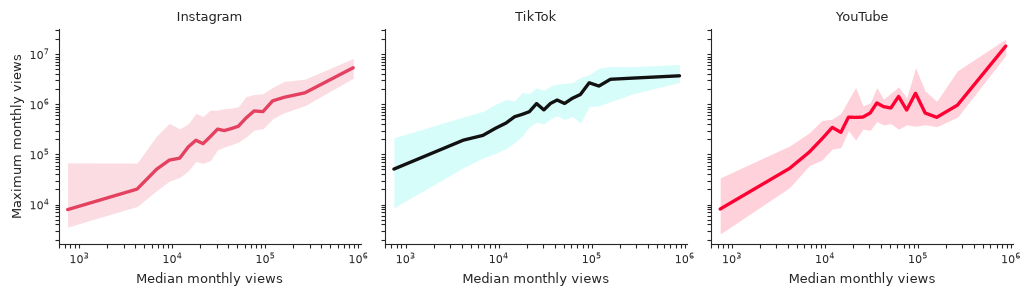

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = all_vc[['publisher', 'platform', 'published_at', 'views']].copy()
df['published_at'] = pd.to_datetime(df['published_at'])
df['year_month'] = df['published_at'].dt.to_period('M')

agg = (
    df.groupby(['publisher', 'platform', 'year_month'])['views']
    .agg(views_mean='median', views_max='max', n_videos='count')
    .reset_index()
)
agg = agg[agg['n_videos'] >= 5]
agg = agg[(agg['views_mean'] > 0) & (agg['views_max'] > 0)]

# calcolo i bin edges dei decili SOLO su Instagram
instagram_mean = agg.loc[agg['platform'] == 'Instagram', 'views_mean']
_, bin_edges = pd.qcut(instagram_mean, q=20, labels=False, duplicates='drop', retbins=True)

# estendo i bordi per includere eventuali valori fuori range nelle altre piattaforme
bin_edges_ext = bin_edges.copy()
bin_edges_ext[0] = -np.inf
bin_edges_ext[-1] = np.inf

# assegno lo stesso decile (definito su Instagram) a TUTTE le piattaforme
agg['decile'] = pd.cut(agg['views_mean'], bins=bin_edges_ext, labels=False, include_lowest=True)

n_deciles = len(bin_edges_ext) - 1

# posizione x di ogni decile = media geometrica del bin (coerente con scala log)
bin_centers = [np.sqrt(bin_edges[k] * bin_edges[k+1]) for k in range(len(bin_edges) - 1)]

platforms = agg['platform'].unique()
n = len(platforms)
ncols = 3
nrows = -(-n // ncols)
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------------------------------------------------
# Science-like style
# -----------------------------------------------------------------------------
sns.set_theme(
    style="ticks",
    context="paper",
    font_scale=1.1,
)

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 8,
    "axes.labelsize": 9,
    "axes.titlesize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# -----------------------------------------------------------------------------
# Platform colors
# -----------------------------------------------------------------------------
line_colors = {
    "Instagram": "#E4405F",
    "TikTok": "#111111",
    "YouTube": "#FF0033",
}

fill_colors = {
    "Instagram": "#E4405F",
    "TikTok": "#25F4EE",
    "YouTube": "#FF0033",
}
# -----------------------------------------------------------------------------
# Summary statistics
# -----------------------------------------------------------------------------
summary = (
    agg.groupby(["platform", "decile"])
       .agg(
           median=("views_max", "median"),
           q25=("views_max", lambda x: x.quantile(.25)),
           q75=("views_max", lambda x: x.quantile(.75)),
       )
       .reset_index()
)

summary["x"] = summary["decile"].map(dict(enumerate(bin_centers)))

# -----------------------------------------------------------------------------
# Facets
# -----------------------------------------------------------------------------
g = sns.FacetGrid(
    summary,
    col="platform",
    col_wrap=3,
    height=3.0,
    aspect=1.15,
    sharex=True,
    sharey=True,
    despine=True,
)

def plot_platform(data, **kwargs):

    ax = plt.gca()

    platform = data["platform"].iloc[0]

    ax.fill_between(
        data["x"],
        data["q25"],
        data["q75"],
        color=fill_colors[platform],
        alpha=0.18,
        linewidth=0,
    )

    ax.plot(
        data["x"],
        data["median"],
        color=line_colors[platform],
        lw=2.4,
        solid_capstyle="round",
    )

    ax.set_xscale("log")
    ax.set_yscale("log")

    sns.despine(ax=ax)
g.map_dataframe(plot_platform)

g.set_axis_labels(
    "Median monthly views",
    "Maximum monthly views",
)

g.set_titles("{col_name}")

for ax in g.axes.flat:

    ax.tick_params(length=3, width=0.8)

    ax.set_xlim(min(bin_centers)*0.8, max(bin_centers)*1.2)

plt.tight_layout()

# plt.savefig("figure.pdf", dpi=600, bbox_inches="tight")
plt.show()